In [2]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_train = pd.read_csv("track_a_rental_pricing_test.csv")
df_test = pd.read_csv("track_a_rental_pricing_train.csv")


X_train = df_train.drop(columns=['rent_eur_month'])
Y_train = df_train['rent_eur_month']

X_test = df_test.drop(columns= ['rent_eur_month'])
Y_test = df_test['rent_eur_month']


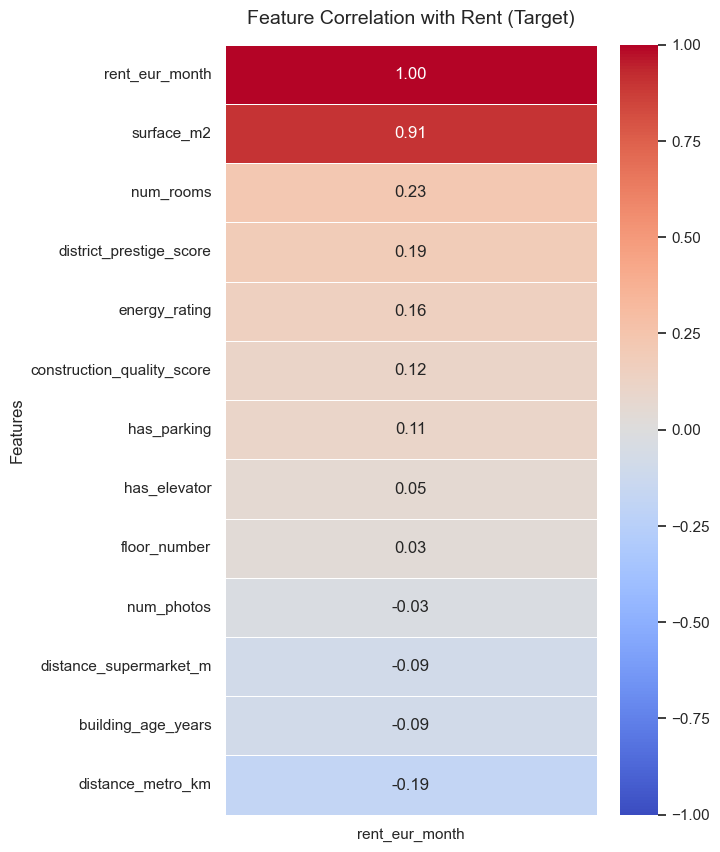

In [7]:
df_train_numeric = df_train.select_dtypes(include=['number'])

numeric_df = df_train.select_dtypes(include=["number"])

# 3. Calculate the Spearman correlation matrix
# (Spearman is ideal here since rental features often include mixed integers like bedrooms/bathrooms and binary indicators)
corr_matrix = numeric_df.corr(method="spearman")

# 4. Isolate just the 'rent' column and sort the values
rent_corr = corr_matrix[["rent_eur_month"]].sort_values(by="rent_eur_month", ascending=False)

# 5. Plot a clean, single-column heatmap
plt.figure(figsize=(6, 10))
sns.heatmap(
    rent_corr,
    annot=True,  # Shows the exact correlation coefficients
    cmap="coolwarm",  # Red = positive correlation, Blue = negative correlation
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)

plt.title("Feature Correlation with Rent (Target)", fontsize=14, pad=15)
plt.ylabel("Features")
plt.show()

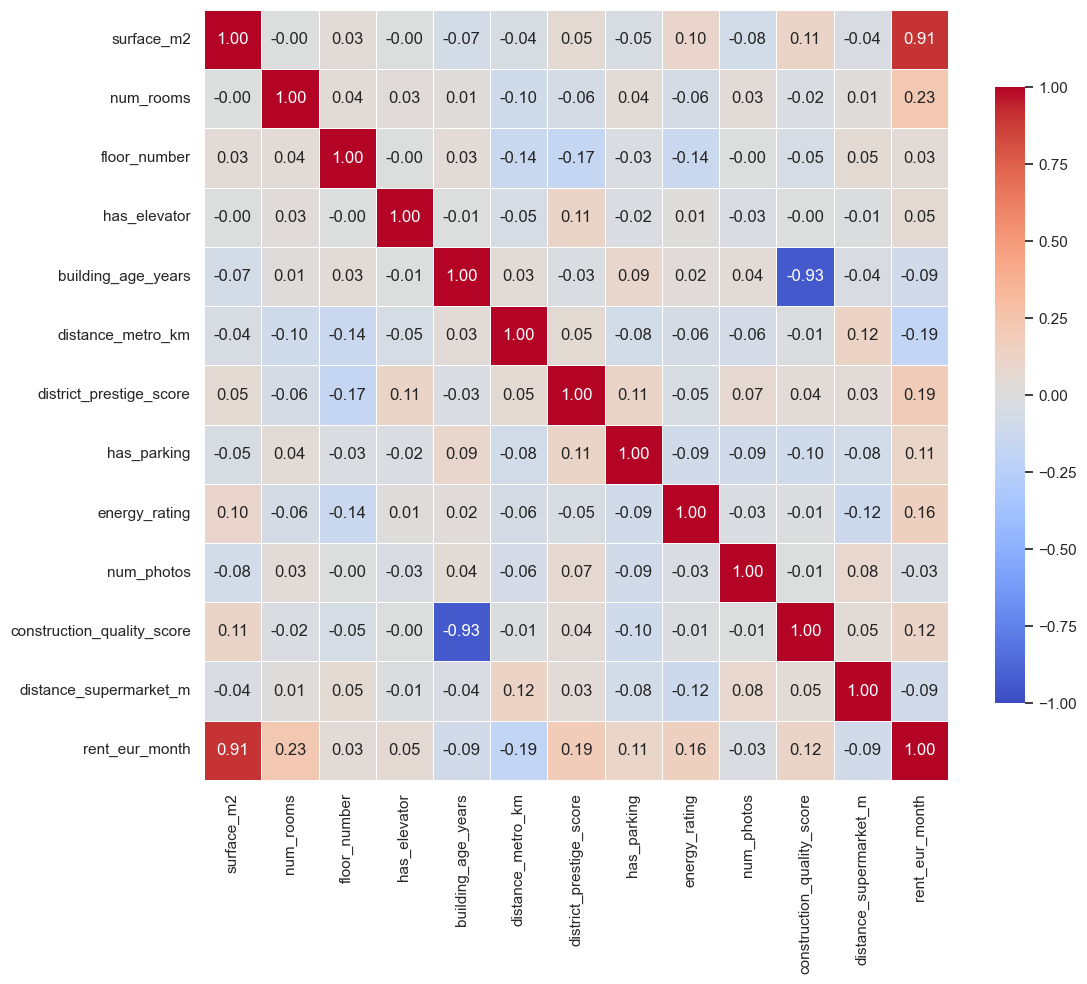

In [4]:
numeric_df = df_train.select_dtypes(include=["number"])

# 3. Calculate Spearman correlation matrix
# (Best for mixed data types as it evaluates monotonic relationships/ranks)
corr_matrix = numeric_df.corr(method="spearman")

# 4. Set up the plotting style and dimensions without using plt.figure()
sns.set_theme(style="white", rc={"figure.figsize": (12, 10)})

# 5. Draw the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,  # Shows the correlation numbers inside the boxes
    cmap="coolwarm",  # Red for positive, Blue for negative correlation
    fmt=".2f",  # Rounds numbers to 2 decimal places
    vmin=-1,
    vmax=1,  # Forces scale from -1 to 1
    linewidths=0.5,  # Adds thin lines between cells for readability
    cbar_kws={"shrink": 0.8},  # Shrinks colorbar slightly to fit nicely
)

# 6. Save the heatmap as an image file
plt.savefig("correlation_matrix.png", dpi=300, bbox_inches="tight")

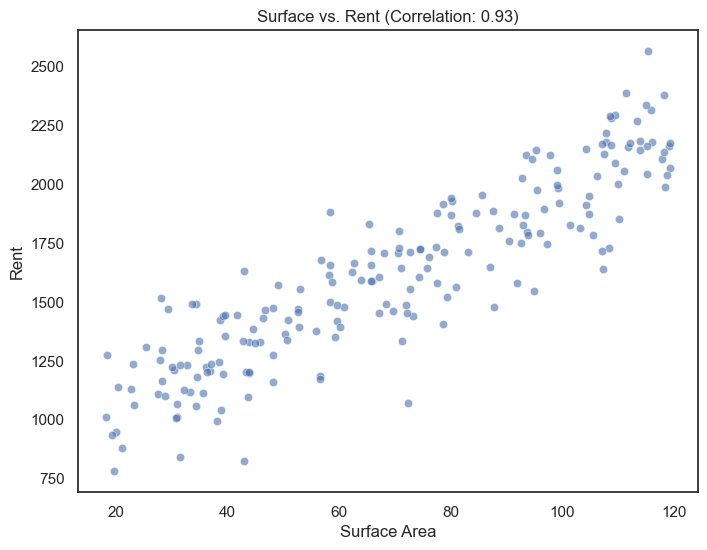

In [8]:
# Replace 'rent' with whatever your exact target column name is
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_train, x="surface_m2", y="rent_eur_month", alpha=0.6)
plt.title("Surface vs. Rent (Correlation: 0.93)")
plt.xlabel("Surface Area")
plt.ylabel("Rent")
plt.show()

Observe a huge correlation between rent and surface. No outliers when observing just the surface.

In [13]:
# 1. Calculate price per surface unit
df_train["rent_per_surface"] = df_train["rent_eur_month"] / df_train["surface_m2"]

# 2. Check the new correlations
print(
    "Correlation with Rent per Surface:"
)
print(
    df_train[["building_age_years", "construction_quality_score"]].corrwith(
        df_train["rent_per_surface"], method="spearman"
    )
)

Correlation with Rent per Surface:
building_age_years            0.031734
construction_quality_score   -0.073428
dtype: float64


Huge negative correlation between quality score and building age years

Let us set up a baseline model (LR)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Initialize and train the baseline
baseline_model = LinearRegression()
baseline_model.fit(X_train, Y_train)

Y_pred_train = baseline_model.predict(X_train)
Y_pred_test = baseline_model.predict(X_test)

mse_train = mean_squared_error(Y_train, Y_pred_train)
mse_test = mean_squared_error(Y_test, Y_pred_test)


# 5. Print the results
print("--- Baseline Linear Regression Performance ---")
print(f"Training R-squared: {r2_score(Y_train, Y_pred_train):.4f}")
print(f"Testing R-squared:  {r2_score(Y_test, Y_pred_test):.4f}")
print("-" * 40)
print(f"Training MSE:       {mse_train:.2f}")
print(f"Testing MSE:        {mse_test:.2f}")

# Optional but highly recommended: Root Mean Squared Error (RMSE)
# RMSE brings the error back to the original units (Euros per month)
print("-" * 40)
print(f"Training RMSE:      €{np.sqrt(mse_train):.2f}")
print(f"Testing RMSE:       €{np.sqrt(mse_test):.2f}")

--- Baseline Linear Regression Performance ---
Training R-squared: 0.9440
Testing R-squared:  0.9202
----------------------------------------
Training MSE:       8065.85
Testing MSE:        10497.98
----------------------------------------
Training RMSE:      €89.81
Testing RMSE:       €102.46


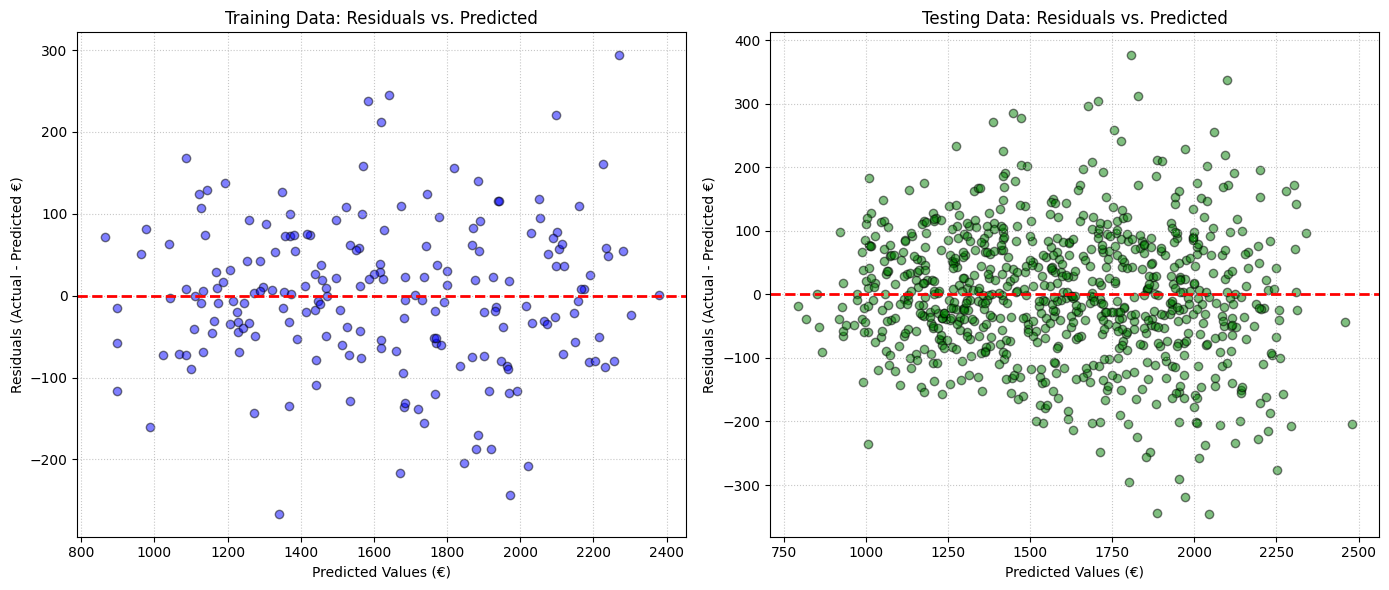

In [21]:
import matplotlib.pyplot as plt

# 1. Calculate the residuals (Actual - Predicted)
residuals_train = Y_train - Y_pred_train
residuals_test = Y_test - Y_pred_test

# 2. Set up the plotting area (1 row, 2 columns)
plt.figure(figsize=(14, 6))

# 3. Plot Training Residuals
plt.subplot(1, 2, 1)
plt.scatter(Y_pred_train, residuals_train, alpha=0.5, color='blue', edgecolors='k')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2) # The zero-error line
plt.title('Training Data: Residuals vs. Predicted')
plt.xlabel('Predicted Values (€)')
plt.ylabel('Residuals (Actual - Predicted €)')
plt.grid(True, linestyle=':', alpha=0.7)

# 4. Plot Testing Residuals
plt.subplot(1, 2, 2)
plt.scatter(Y_pred_test, residuals_test, alpha=0.5, color='green', edgecolors='k')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Testing Data: Residuals vs. Predicted')
plt.xlabel('Predicted Values (€)')
plt.ylabel('Residuals (Actual - Predicted €)')
plt.grid(True, linestyle=':', alpha=0.7)

# 5. Display the graphs
plt.tight_layout()
plt.show()

Slight heterosckedasticity, try apply log-transform


In [22]:

# 1. Log-transform the target variable for training
Y_train_log = np.log(Y_train)
Y_test_log = np.log(Y_test)

# 2. Train the model on the log-transformed data
log_model = LinearRegression()
log_model.fit(X_train, Y_train_log)

# 3. Predict on the log scale
Y_pred_train_log = log_model.predict(X_train)
Y_pred_test_log = log_model.predict(X_test)

# 4. Convert predictions back to the original scale (Euros) using exponentiation
Y_pred_train_final = np.exp(Y_pred_train_log)
Y_pred_test_final = np.exp(Y_pred_test_log)

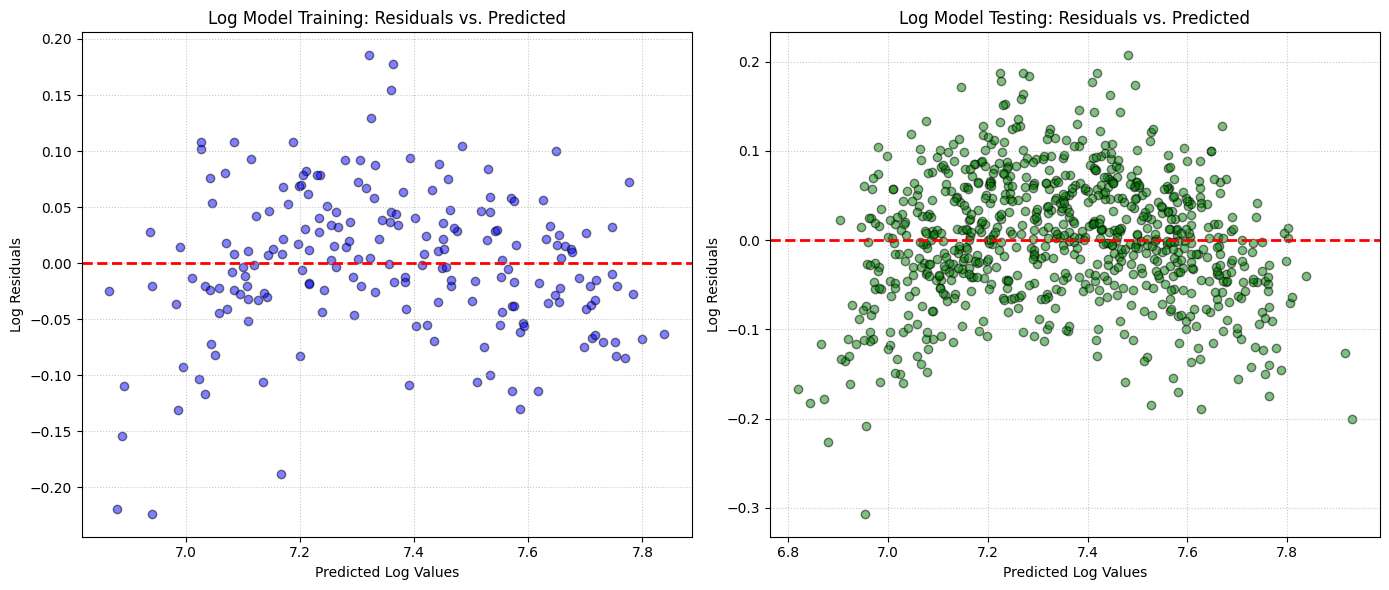

In [23]:
import matplotlib.pyplot as plt

# 1. Calculate the residuals on the LOG scale (Actual Log - Predicted Log)
residuals_train_log = Y_train_log - Y_pred_train_log
residuals_test_log = Y_test_log - Y_pred_test_log

# 2. Set up the plotting area (1 row, 2 columns)
plt.figure(figsize=(14, 6))

# 3. Plot Log Training Residuals
plt.subplot(1, 2, 1)
plt.scatter(Y_pred_train_log, residuals_train_log, alpha=0.5, color='blue', edgecolors='k')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Log Model Training: Residuals vs. Predicted')
plt.xlabel('Predicted Log Values')
plt.ylabel('Log Residuals')
plt.grid(True, linestyle=':', alpha=0.7)

# 4. Plot Log Testing Residuals
plt.subplot(1, 2, 2)
plt.scatter(Y_pred_test_log, residuals_test_log, alpha=0.5, color='green', edgecolors='k')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Log Model Testing: Residuals vs. Predicted')
plt.xlabel('Predicted Log Values')
plt.ylabel('Log Residuals')
plt.grid(True, linestyle=':', alpha=0.7)

# 5. Display the graphs
plt.tight_layout()
plt.show()

Heterosckedasticity removed, but observe a non-linear shape. Let's us try a polynomail

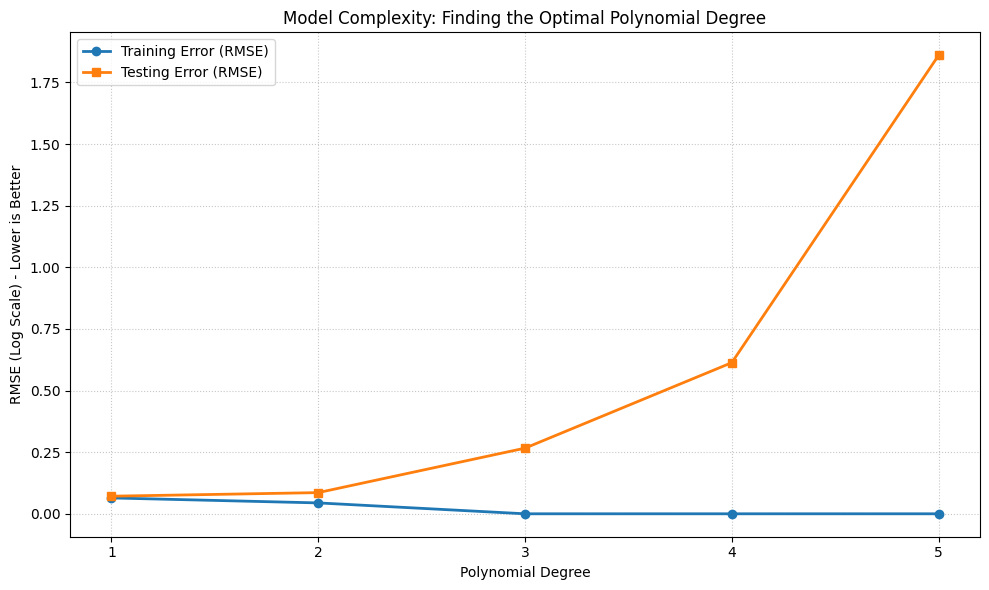

In [27]:
from sklearn.preprocessing import PolynomialFeatures

# 1. Define the degrees you want to test
degrees = [1, 2, 3, 4, 5]

# Lists to store our error metrics
train_rmse_list = []
test_rmse_list = []

for d in degrees:
    # 2. Create polynomial features for the current degree
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    # 3. Train the model (Remember to keep using your log-transformed Y!)
    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, Y_train_log)
    
    # 4. Generate predictions
    Y_pred_train = poly_model.predict(X_train_poly)
    Y_pred_test = poly_model.predict(X_test_poly)
    
    # 5. Calculate Root Mean Squared Error (RMSE) on the log scale
    train_rmse = np.sqrt(mean_squared_error(Y_train_log, Y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(Y_test_log, Y_pred_test))
    
    # Store the results
    train_rmse_list.append(train_rmse)
    test_rmse_list.append(test_rmse)

# 6. Plot the Complexity Curve (Train Error vs. Test Error)
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_rmse_list, label='Training Error (RMSE)', marker='o', linewidth=2)
plt.plot(degrees, test_rmse_list, label='Testing Error (RMSE)', marker='s', linewidth=2)

plt.title('Model Complexity: Finding the Optimal Polynomial Degree')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE (Log Scale) - Lower is Better')
plt.xticks(degrees)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# 1. Create the Pipeline
# This chains the transformation and the model together
pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('model', LinearRegression())
])

# 2. Define the Hyperparameter Grid
# The syntax 'poly__degree' tells the pipeline to test the 'degree' parameter inside the 'poly' step
param_grid = {
    'poly__degree': [1, 2, 3, 4, 5]
}

# 3. Initialize GridSearchCV
# cv=5 means 5-Fold Cross-Validation
# scoring='neg_mean_squared_error' is used because scikit-learn always tries to *maximize* the score, 
# so it uses negative errors (closer to 0 is better).
grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error'
)

# 4. Run the Grid Search! 
# We fit this ONLY on the training data, still using the log-transformed Y
print("Running Grid Search Cross-Validation...")
grid_search.fit(X_train, Y_train_log)

# 5. Extract the best parameters and the best trained model
best_degree = grid_search.best_params_['poly__degree']
best_pipeline = grid_search.best_estimator_

print("-" * 45)
print(f"🏆 Best Polynomial Degree Found: {best_degree}")
print("-" * 45)

# 6. Evaluate the winning model on your completely unseen Testing Set
Y_pred_test_best = best_pipeline.predict(X_test)
best_test_rmse = np.sqrt(mean_squared_error(Y_test_log, Y_pred_test_best))

print(f"Final Testing RMSE (Log Scale): {best_test_rmse:.4f}")

Running Grid Search Cross-Validation...
---------------------------------------------
🏆 Best Polynomial Degree Found: 1
---------------------------------------------
Final Testing RMSE (Log Scale): 0.0714


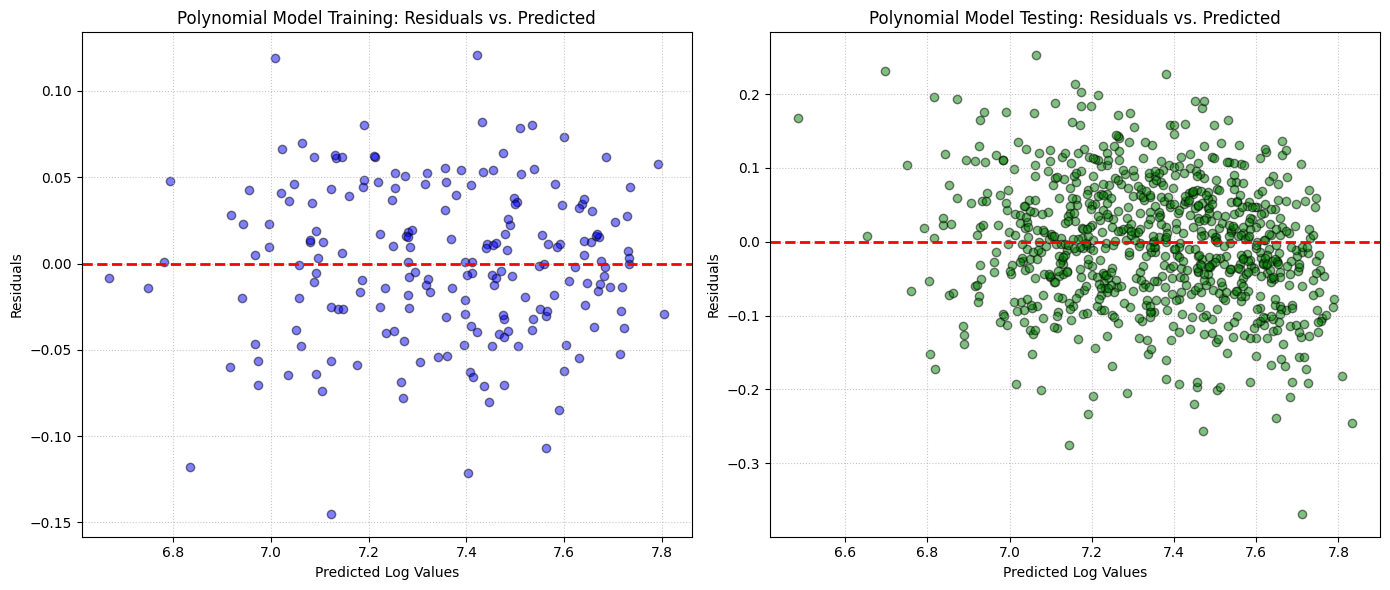

In [ ]:
# Calculate the new polynomial residuals
residuals_train_poly = Y_train_log - Y_pred_train_poly
residuals_test_poly = Y_test_log - Y_pred_test_poly

# Set up the plotting area
plt.figure(figsize=(14, 6))

# Plot Training Data
plt.subplot(1, 2, 1)
plt.scatter(Y_pred_train_poly, residuals_train_poly, alpha=0.5, color='blue', edgecolors='k')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Polynomial Model Training: Residuals vs. Predicted')
plt.xlabel('Predicted Log Values')
plt.ylabel('Residuals')
plt.grid(True, linestyle=':', alpha=0.7)

# Plot Testing Data
plt.subplot(1, 2, 2)
plt.scatter(Y_pred_test_poly, residuals_test_poly, alpha=0.5, color='green', edgecolors='k')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Polynomial Model Testing: Residuals vs. Predicted')
plt.xlabel('Predicted Log Values')
plt.ylabel('Residuals')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

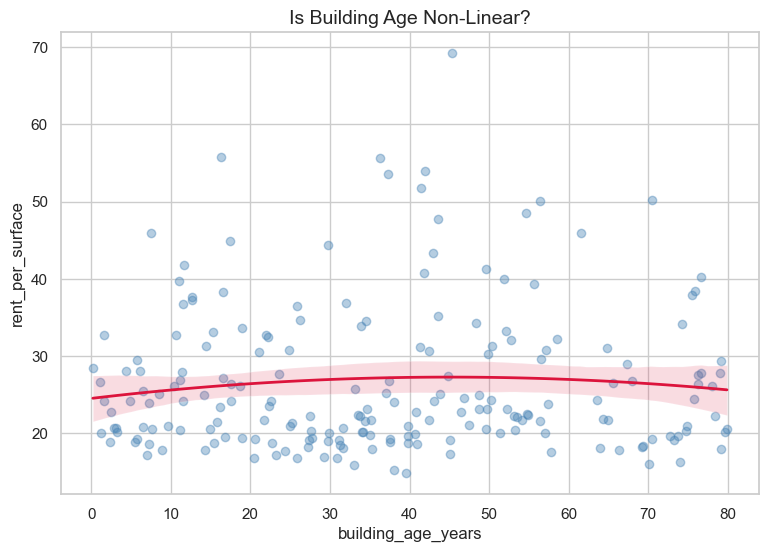

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))
# order=2 forces seaborn to draw a quadratic curve instead of a straight line
sns.regplot(
    data=df_train,
    x="building_age_years",
    y="rent_per_surface",
    order=2,
    scatter_kws={"alpha": 0.4, "color": "steelblue"},
    line_kws={"color": "crimson", "linewidth": 2},
)
plt.title("Is Building Age Non-Linear?", fontsize=14)
plt.show()